# The Park That Never Came: Bushwick Inlet in the Minutes, 2016–2026

In 2005, New York rezoned the Williamsburg–Greenpoint waterfront for towers and
promised the neighborhood a ~28-acre park at Bushwick Inlet in exchange. Two
decades later the park is still a patchwork of acquired-but-unbuilt parcels —
a fuel depot, a burned warehouse site, a gas-plant remediation zone, an MTA lot.

This notebook traces how that broken promise lived inside Brooklyn Community
Board 1's own meeting minutes for ten years: what the board heard, what it
voted on (unanimously, for years), and how the saga finally broke open in
2025–26 — not as a park, but as three residential towers with park money
attached.

Sources: the full text of ~108 CB1 meetings (body pages + OCR'd scans) plus
the structured votes/speakers dataset. Post-CB1 outcomes (Borough President,
City Planning, Council) are cited from news coverage at the end — they're
outside this corpus.

In [1]:
import json
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# ---- full-text index: meeting_id -> complete minutes text ----
meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
sha2mid = {f["sha256"]: mid for mid, m in meet.items() for f in m["files"]}

texts = {}
for tf in Path("../data/interim/text").glob("*.json"):
    mid = sha2mid.get(tf.stem)
    if mid:
        texts[mid] = texts.get(mid, "") + " " + " ".join(json.loads(tf.read_text()))
# overlay vision-OCR transcripts (the 2016-18 scan era has no text layer)
for of in Path("../data/interim/ocr").glob("*.txt"):
    mid = sha2mid.get(of.name[:64])
    if mid:
        texts[mid] = texts.get(mid, "") + " " + of.read_text()

lower = {mid: t.lower() for mid, t in texts.items()}
dates = {mid: m["date"] for mid, m in meet.items()}

def mentions(term):
    return pd.DataFrame(
        [(mid, dates[mid], lower[mid].count(term)) for mid in lower if term in lower[mid]],
        columns=["meeting_id", "date", "n"],
    ).sort_values("date")

def context(term, mid, width=170, k=2):
    out = []
    for m in re.finditer(re.escape(term), lower[mid]):
        s = max(0, m.start() - width)
        out.append(" ".join(texts[mid][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

print(f"full-text index: {len(texts)} meetings, {sum(len(t) for t in texts.values())/1e6:.0f}M chars")

full-text index: 108 meetings, 24M chars


## One chart, ten years

Mentions of each saga thread, by meeting. Bushwick Inlet itself is the
steady drumbeat; each parcel flares when its moment comes — and the bright
band at the bottom right is Monitor Point arriving in 2025.

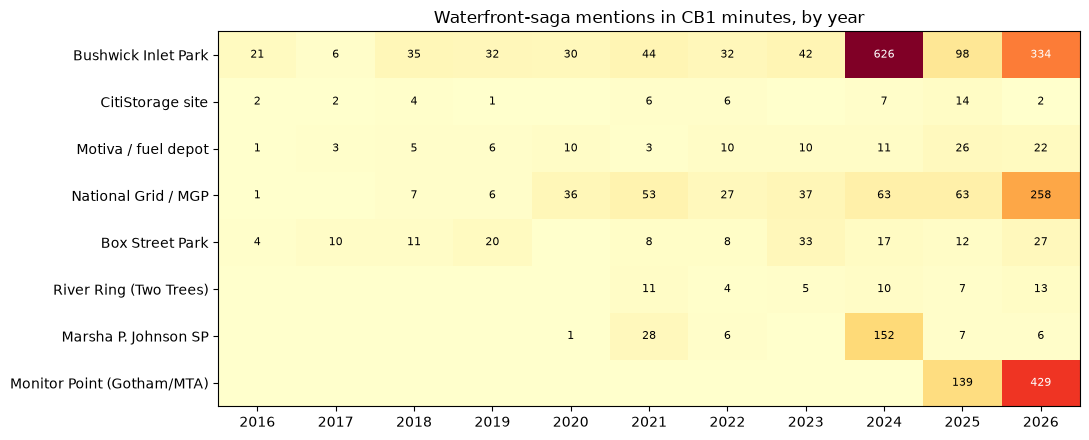

In [2]:
TERMS = {
    "bushwick inlet": "Bushwick Inlet Park",
    "citistorage": "CitiStorage site",
    "motiva": "Motiva / fuel depot",
    "national grid": "National Grid / MGP",
    "box street": "Box Street Park",
    "river ring": "River Ring (Two Trees)",
    "marsha p": "Marsha P. Johnson SP",
    "monitor point": "Monitor Point (Gotham/MTA)",
}
rows = []
for term, label in TERMS.items():
    for mid, t in lower.items():
        n = t.count(term)
        if n:
            rows.append({"label": label, "yr": int(dates[mid][:4]), "n": n})
df = pd.DataFrame(rows).groupby(["label", "yr"]).n.sum().unstack(fill_value=0)
df = df.reindex([l for l in TERMS.values() if l in df.index])

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(df.columns)), df.columns)
ax.set_yticks(range(len(df.index)), df.index)
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        v = df.values[i, j]
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=8,
                    color="white" if v > df.values.max() * 0.5 else "black")
ax.set_title("Waterfront-saga mentions in CB1 minutes, by year")
plt.tight_layout()

## Act I (2016–2021): the ritual decade

Every waterfront vote for six years passes **without a single "no"** — the
board writes letters, demands funding, rejects a fuel-depot deal, and asks
three levels of government to keep the 2005 promise. Unanimity is the tell:
this wasn't a debate, it was a grievance.

In [3]:
q("""
    SELECT m.date, v.yes, v.no, v.abstain, substr(v.motion_text, 1, 90) AS motion
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE (v.motion_text ILIKE '%bushwick inlet%' OR v.motion_text ILIKE '%waterfront%'
           OR v.motion_text ILIKE '%box street%' OR v.motion_text ILIKE '%motiva%'
           OR v.motion_text ILIKE '%national grid%')
      AND m.date < '2021-10-01'
    ORDER BY m.date
""")

,date,yes,no,abstain,motion
0,2016-06-14,39,0,0,Motion to have the Parks Department move forwa...
1,2016-10-13,0,0,0,Support the Parks & Waterfront Committee's let...
2,2019-06-11,36,0,0,Send a letter to the Parks Department and EDC ...
3,2019-06-11,36,0,0,Accept the Box Street Park design with recomme...
4,2019-11-12,38,0,0,Motion to send a letter of support for the Fri...
5,2020-02-11,33,0,0,Motion to support the committee's recommendati...
6,2020-02-11,33,0,0,Motion to approve the National Grid pipeline o...
7,2020-06-24,28,0,0,Approval of the Parks & Waterfront Committee's...
8,2020-10-13,36,0,0,Motion to send letters to Mayor de Blasio and ...
9,2020-10-13,29,0,0,Motion to send a letter requesting that the Pa...


### The parcels, in their own words

The park-that-never-was is really four or five land assemblages, each with its
own subplot in the minutes. A few verbatim moments (pulled from the full text):

In [4]:
# for each parcel, quote the meeting where it dominated the conversation
for term, title in [
    ("citistorage", "CitiStorage site"),
    ("motiva", "Motiva fuel depot"),
    ("65 commercial", "65 Commercial St (MTA lot)"),
    ("box street", "Box Street Park"),
]:
    m = mentions(term)
    mid = m.sort_values("n").iloc[-1].meeting_id
    print(f"--- {title}: peak meeting {mid} ({m.n.sum()} mentions overall) ---")
    for c in context(term, mid, k=2):
        print("  ", c[:330])
    print()

--- CitiStorage site: peak meeting cb1-2021-09-14 (44 mentions overall) ---
   ndersigned coalition of North Brooklyn community associations, urgently implore the Office of Management and Budget to allow the funding for the demolition of the former CitiStorage warehouse located at 5 North 11th Street. This building is located within Bushwick Inlet Park. Bushwick Inlet Park was mapped and planned as a 27-ac
   Inlet Park. Bushwick Inlet Park was mapped and planned as a 27-acre park by the City of New York in 2005 as part of the Greenpoint-Williamsburg Waterfront Rezoning. The CitiStorage property was acquired by the city in 2016 with the intent to demolish the building and complete the park. It is our understanding that OMB has preven

--- Motiva fuel depot: peak meeting cb1-2025-04-08 (107 mentions overall) ---
   eet Park –EDC contractors have begun on site work. · Bushwick Inlet Park: CitiStorage Demolition – demolition is complete, awaiting DOB signoff. · Bushwick Inlet Park: Motiva

## Act II (2021): River Ring — the first crack in the consensus

Two Trees' River Ring rezoning (Williamsburg side) is the first waterfront
project that *splits* the neighborhood instead of uniting it. One September
2021 hearing drew 30+ speakers; CB1's own recommendation passed with eight
abstentions — the first non-unanimous waterfront vote in the dataset. The
trade — towers in exchange for public waterfront — prefigured everything
that happened at Monitor Point four years later.

In [5]:
q("""
    SELECT position, count(*) AS speakers
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE s.topic ILIKE '%river ring%' GROUP BY 1 ORDER BY speakers DESC
""")

,position,speakers
0,against,19
1,for,14
2,neutral,3
3,unclear,1


## Act III (2025–26): Monitor Point — the climax

Gotham Organization + the MTA propose three towers (600'/450'/230', ~1,150
units) at 40–56 Quay Street — the MTA lot that park advocates had wanted
*added to the park* (a speaker asked for exactly that in 2018). The fight
runs eight straight meetings. But unlike every earlier act, testimony runs
**pro-development**: housing and labor voices out-organize the park
old guard at both decisive hearings.

position,against,for
meeting,,
2025-06-10,11.0,19.0
2026-01-20,4.0,0.0
2026-02-10,8.0,24.0


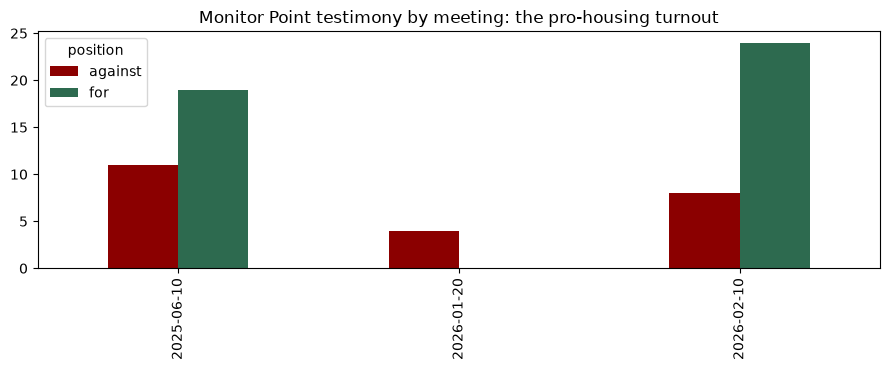

In [6]:
df = q("""
    SELECT m.date::VARCHAR AS meeting, s.position, count(*) AS n
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE s.topic ILIKE '%monitor point%' AND s.position IN ('for', 'against')
    GROUP BY 1, 2 ORDER BY 1
""").pivot(index="meeting", columns="position", values="n").fillna(0)
ax = df[["against", "for"]].plot(kind="bar", figsize=(9, 3.8), color=["#8B0000", "#2d6a4f"])
ax.set_title("Monitor Point testimony by meeting: the pro-housing turnout")
ax.set_xlabel("")
plt.tight_layout()
df

### February 10, 2026: the vote

The meeting plays out like a courtroom drama — a motion to **deny** fails,
a motion to **approve with fifteen conditions** carries 24–9, a companion
demapping application is denied 30–1 to protect the Monitor Museum site,
and the night ends with a failed **censure of the chair** over procedural
games in how the land-use meeting was noticed.

In [7]:
q("""
    SELECT v.yes, v.no, v.abstain, v.outcome, substr(v.motion_text, 1, 100) AS motion
    FROM votes v
    WHERE v.meeting_id = 'cb1-2026-02-10'
      AND (v.motion_text ILIKE '%monitor%' OR v.motion_text ILIKE '%censure%'
           OR v.motion_text ILIKE '%quay%')
    ORDER BY v.no DESC
""")

,yes,no,abstain,outcome,motion
0,12,20,0,failed,To deny application MONITOR POINT: APPLICATION...
1,9,18,6,failed,To censure Chairperson Fuller for directing is...
2,24,9,0,passed,To approve application MONITOR POINT: APPLICAT...
3,30,1,0,passed,To deny application 56 QUAY DEMAPPING: APPLICA...


### The fifteen conditions: a settlement of the 2005 grievance

Read CB1's approval conditions as the neighborhood invoicing twenty years of
broken promises. Park maintenance money, the esplanade before occupancy, the
Monitor Museum guaranteed, and — the tell — **65 Commercial Street demolished
and paved** before the MTA gets its new facility: that's another long-promised
park parcel being pried loose as a side payment.

In [8]:
conds = q("""
    SELECT conditions FROM votes
    WHERE meeting_id = 'cb1-2026-02-10' AND motion_text ILIKE 'To approve%MONITOR%'
""").conditions.iloc[0]
for i, c in enumerate(conds, 1):
    print(f"{i:>2}. {c}")

 1. Bushwick Inlet Park maintenance increased to $600,000 with annual CPI increases
 2. Affordable units increased to healthy majority
 3. 50% local preference for affordable units
 4. Water-born transportation for construction
 5. Transparent affordable lottery process
 6. Increase in G line cars
 7. City-wide equitable upzoning
 8. Public access areas and esplanade completed before TCO
 9. TCO conditioned on Monitor Museum creation
10. Demolition and paving at 65 Commercial Street before MTA facility TCO
11. Robust Brooklyn Waterfront Greenway along Quay Street
12. Bike lanes maintained unimpeded during construction
13. Waterfront public green area remain 40 feet
14. Two publicly accessible restrooms in monitor point building
15. Affordable and market-rate units integrated through western building towers


## Epilogue (outside this corpus)

CB1's vote is advisory — the first stop in ULURP. What happened next, per news
coverage: Borough President Reynoso
[signed on in March 2026](https://brooklyndowntownstar.com/lead_story/2026/03/20/monitor-point-reynosos-a-yes/),
the City Planning Commission heard the application March 18, and the
**City Council approved Monitor Point in late June 2026** with affordability
negotiated up to ~50% of 1,150 units
([The Real Deal](https://therealdeal.com/new-york/2026/06/25/nyc-council-oks-gothams-monitor-point-after-zoning-fight/),
[NY YIMBY](https://newyorkyimby.com/2026/02/brooklyn-community-board-1-votes-in-support-of-monitor-point-development-at-40-56-quay-stret-in-greenpoint-brooklyn.html),
[MTA](https://www.mta.info/press-release/mta-unveils-monitor-point-proposal-redevelop-40-quay-street-mixed-income-housing)).

So: the area is finally changing — towers first, park money attached. The
2005 park promise didn't get kept; it got *settled*.

## Method notes

- Mention counts come from the full extracted text (native/embedded text layer
  plus vision-OCR transcripts). 2016–18 scan-era coverage is body-pages-only,
  so early-era counts are a floor, not a ceiling.
- CB votes are advisory; tallies and conditions are extracted from the minutes
  with verbatim source snippets (spot-checked for every claim above).
- The 2005 rezoning history predates the corpus and is provided as context.